<script type="text/javascript" src="https://cdnjs.cloudflare.com/ajax/libs/mathjax/2.7.7/MathJax.js?config=TeX-MML-AM_CHTML"></script>
# Assignment: GNN Scalability & Equivariance

# Introduction

This assignment scales GNNs to real-world data, diagnoses their fundamental pathologies, and introduces equivariant architectures.

1. **Cora Citation Network**: Train a GNN on the Cora dataset and visualize how message passing improves feature quality.
2. **Oversmoothing & Oversquashing**: Measure how depth degrades GNN performance via Dirichlet energy.
3. **Equivariant GNNs**: Implement an E(n)-equivariant GNN and compare it against a standard GNN on a physics simulation task.

In [18]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import pickle
import requests

import numpy as np
import scipy.sparse as sp

import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

torch.manual_seed(42)
np.random.seed(42)

Using device: cuda


<div class="alert alert-info">
    <h3>Utility: GNNLayer from Assignment 1</h3>
    Nothing to do here, just run the cell. This is the same GNNLayer implemented in the previous assignment, reused here for the Cora and oversmoothing experiments.
</div>

In [19]:
class GNNLayer(nn.Module):
    def __init__(self, in_features, out_features, activation=F.relu):
        super().__init__()
        self.activation = activation
        self.w_self = nn.Linear(in_features, out_features)
        self.w_neigh = nn.Linear(in_features, out_features)

    def message(self, x, adj):
        return torch.matmul(adj, x)

    def update(self, x, messages):
        out = self.w_self(x) + self.w_neigh(messages)
        return self.activation(out) if self.activation else out

    def forward(self, x, adj):
        return self.update(x, self.message(x, adj))

# Part 1: Cora Citation Network

The **Cora** dataset is a citation network: nodes are papers, edges are citations. Each node has a 1433-dimensional bag-of-words feature vector. The task is to classify papers into 7 topics.

<div class="alert alert-info">
    <h3>Utility: Cora Loading & TSNE Function</h3>
    Nothing to do here, just run the cell. We load the Cora citation network and provide a TSNE visualization tool.
</div>

In [20]:
def load_cora():
    base_url = "https://github.com/kimiyoung/planetoid/raw/master/data/"
    names = ["x", "tx", "allx", "y", "ty", "ally", "graph", "test.index"]
    objects = []

    for name in names:
        url = f"{base_url}ind.cora.{name}"
        resp = requests.get(url)
        if name == "test.index":
            objects.append(np.genfromtxt(resp.iter_lines(), dtype=np.int32))
        else:
            objects.append(pickle.loads(resp.content, encoding="latin1"))

    x, tx, allx, _, ty, ally, graph, test_idx_reorder = objects
    # features
    test_idx_range = np.sort(test_idx_reorder)
    features = sp.vstack((allx, tx)).tolil()
    features[test_idx_reorder, :] = features[test_idx_range, :]
    x = torch.FloatTensor(np.array(features.todense()))
    # labels
    labels_combined = np.vstack((ally, ty))
    labels_combined[test_idx_reorder, :] = labels_combined[test_idx_range, :]
    labels = torch.LongTensor(np.argmax(labels_combined, axis=1))
    # adjacency matrix
    num_nodes = x.shape[0]
    adj = sp.lil_matrix((num_nodes, num_nodes))
    for node, neighbors in graph.items():
        for neighbor in neighbors:
            adj[node, neighbor] = 1
            adj[neighbor, node] = 1
    adj = np.array(adj.todense())
    # symmetric normalization: D^{-1/2} (A + I) D^{-1/2}
    adj_tilde = adj + np.eye(num_nodes)
    deg = adj_tilde.sum(axis=1)
    deg_inv_sqrt = np.diag(1.0 / np.sqrt(deg))
    adj_norm = torch.FloatTensor(deg_inv_sqrt @ adj_tilde @ deg_inv_sqrt)
    return x.to(device), adj_norm.to(device), labels.to(device)


def plot_tsne(embeddings, labels, title="TSNE Projection"):
    tsne = TSNE(n_components=2, random_state=42)
    out_2d = tsne.fit_transform(embeddings.detach().cpu().numpy())
    if isinstance(labels, torch.Tensor):
        labels = labels.cpu()
    plt.figure(figsize=(10, 8))
    plt.scatter(out_2d[:, 0], out_2d[:, 1], c=labels, cmap="tab10", s=15, alpha=0.7)
    plt.title(title)
    plt.colorbar(label="Class")
    

x_cora, adj_cora, labels_cora = load_cora()

print(f"Features: {x_cora.shape}")
print(f"Adjacency: {adj_cora.shape}")
print(f"Labels: {labels_cora.shape}")

C:\Users\stec\AppData\Local\Temp\ipykernel_21068\1738088594.py:12: DeprecationWarning: Please import `csr_matrix` from the `scipy.sparse` namespace; the `scipy.sparse.csr` namespace is deprecated and will be removed in SciPy 2.0.0.
  objects.append(pickle.loads(resp.content, encoding="latin1"))


Features: torch.Size([2708, 1433])
Adjacency: torch.Size([2708, 2708])
Labels: torch.Size([2708])


<div class="alert alert-warning">
    <h3>Task 1.1: Cora Training [1 pt]</h3>
    Train a 2-layer GNN on the Cora dataset with <b>cross entropy loss</b>.<br>
    <i>Tip: Cora has 1433 input features and 7 output classes.</i>
</div>

In [21]:
class CoraModel(nn.Module):
    def __init__(self, in_d, hidden_d, out_d):
        super().__init__()
        self.l1 = GNNLayer(in_d, hidden_d)
        self.l2 = GNNLayer(hidden_d, out_d, activation=None)

    def forward(self, x, adj):
        return self.l2(self.l1(x, adj), adj)


# YOUR CODE HERE

model = CoraModel(in_d=1433, hidden_d=64, out_d=7).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

num_epochs = 200

for epoch in range(num_epochs):
    model.train()

    optimizer.zero_grad()

    out_cora = model(x_cora, adj_cora)

    loss = F.cross_entropy(out_cora, labels_cora)

    loss.backward()

    optimizer.step()

    if epoch % 20 == 0:
        pred = out_cora.argmax(dim=1)
        acc = (pred == labels_cora).float().mean()
        print(f"Epoch {epoch:03d} | Loss: {loss.item():.4f} | Accuracy: {acc.item():.4f}")


model.eval()

with torch.no_grad():
    out_cora = model(x_cora, adj_cora)
    pred = out_cora.argmax(dim=1)
    acc = (pred == labels_cora).float().mean()

print(f"Final Accuracy: {acc.item():.4f}")

Epoch 000 | Loss: 1.9480 | Accuracy: 0.1296
Epoch 020 | Loss: 0.0348 | Accuracy: 0.9956
Epoch 040 | Loss: 0.0228 | Accuracy: 1.0000
Epoch 060 | Loss: 0.0210 | Accuracy: 1.0000
Epoch 080 | Loss: 0.0172 | Accuracy: 1.0000
Epoch 100 | Loss: 0.0148 | Accuracy: 1.0000
Epoch 120 | Loss: 0.0133 | Accuracy: 1.0000
Epoch 140 | Loss: 0.0123 | Accuracy: 1.0000
Epoch 160 | Loss: 0.0116 | Accuracy: 1.0000
Epoch 180 | Loss: 0.0111 | Accuracy: 1.0000
Final Accuracy: 1.0000


<div class="alert alert-info">
    <h3>Raw Cora vs TSNE GNN embeddings</h3>
    Nothing to do here, just run the cell. We compare the TSNE of raw bag-of-words features vs. the TSNE of GNN embeddings to see the effect of message passing.
</div>

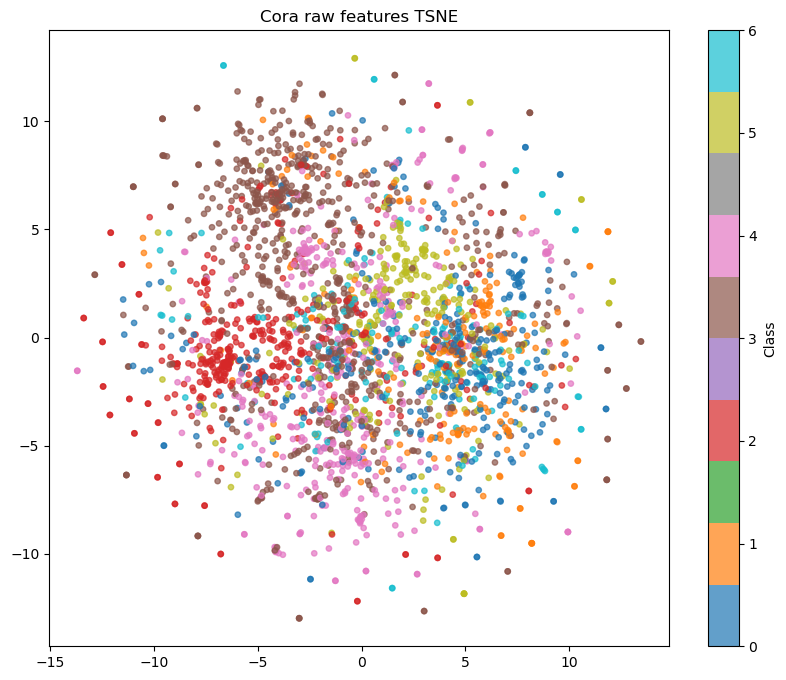

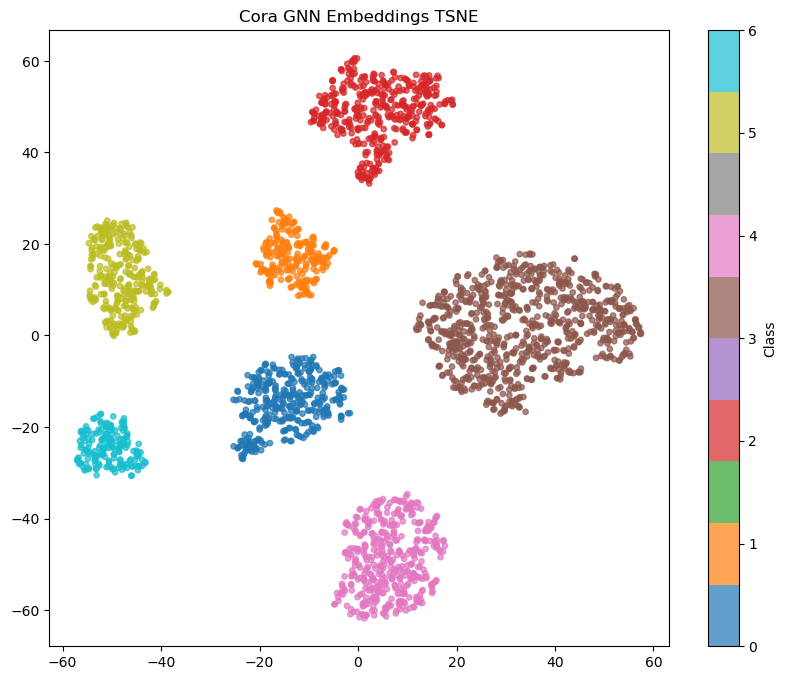

In [22]:
plot_tsne(x_cora, labels_cora, title="Cora raw features TSNE")
plot_tsne(out_cora, labels_cora, title="Cora GNN Embeddings TSNE")

<div class="alert alert-warning">
    <h3>Question 1.2 [1 pt]</h3>
    Compare the two TSNE projections (raw features vs GNN embeddings).
    <ol>
        <li>Why do GNN embeddings produce better-separated clusters than raw bag-of-words features?</li>
        <li>Consider the message passing update \(\mathbf{h}_i^{(k)} = \phi\!\left(\mathbf{h}_i^{(k-1)}, \bigoplus_{j \in \mathcal{N}(i)} \psi(\mathbf{h}_j^{(k-1)})\right)\). If two papers \(i, j\) are in the same topic and are connected by a citation, what happens to their embeddings after one layer of message passing? What if they are in different topics?</li>
    </ol>
    Write your answer in the cell below.
<br><i>Note: answering one part thoroughly is sufficient for full credit.</i>
</div>

*Your answer here.*

GNN embeddings form better-separated clusters because they combine each paper’s bag-of-words features with information from neighboring papers, and papers connected by citations often belong to similar topics. 

After one message-passing layer, two connected papers from the same topic will receive similar neighborhood information and their embeddings become more similar, while connected papers from different topics may mix some information but usually remain more separated if their broader neighborhoods differ.

# Part 2: Oversmoothing & Oversquashing

As we stack more message passing layers, node representations converge to indistinguishable states (**oversmoothing**). Intuitively, $k$ layers of message passing let each node aggregate information from its $k$-hop neighborhood. When $k$ exceeds the graph diameter, every node sees the entire graph — and the aggregated representations collapse.

We quantify this with the **Dirichlet energy**:

$$
E(\mathbf{H}) = \frac{1}{N} \sum_{(i,j) \in \mathcal{E}} \|\mathbf{h}_i - \mathbf{h}_j\|^2
$$

This measures how much embeddings vary across edges. For node classification, we need $E > 0$ so that different-class neighbors remain separable. The normalized adjacency $\hat{A} = D^{-1/2}(A+I)D^{-1/2}$ acts as a **low-pass filter** on the graph: each multiplication smooths the signal. In the spectral domain, repeated application of $\hat{A}$ suppresses all eigenvector components except the leading one, driving $E \to 0$ — the oversmoothing limit.

**Oversquashing** is a related but distinct phenomenon: when information from node $j$ must reach distant node $i$ through a bottleneck, the Jacobian $\partial \mathbf{h}_i^{(k)} / \partial \mathbf{h}_j^{(0)}$ decays exponentially with distance, related to the graph's Cheeger constant.

A simple mitigation is **residual (skip) connections**: $\mathbf{h}^{(k+1)} = \mathbf{h}^{(k)} + \text{GNNLayer}(\mathbf{h}^{(k)})$. By preserving the input signal, skip connections prevent representations from collapsing entirely. A more principled approach is **PPNP** (Klicpera et al., *Predict then Propagate*, ICLR 2019), which decouples prediction from propagation using personalized PageRank with a teleport probability $\alpha$ that controls how much the original features are retained.

<div class="alert alert-warning">
    <h3>Task 2.1: Oversmoothing Experiment [1 pt]</h3>
    <ol>
        <li>Build a <code>DeepGNN</code> class that takes a variable number of layers.</li>
        <li>Write a <code>depth_scan(model_class, depths)</code> function that, for each depth:
            <ul>
                <li>Instantiates and trains the model on Cora with <b>cross entropy loss</b>.</li>
                <li>Records classification <b>accuracy</b> and <b>Dirichlet energy</b> of the output embeddings.</li>
            </ul>
        </li>
        <li>Run the scan for <code>DeepGNN</code> with depths <b>[2, 4, 8, 16, 32]</b>.</li>
    </ol>
    <i>Tip: the <code>dirichlet_energy</code> function is provided below. You will reuse <code>depth_scan</code> in Task 2.2.</i>
</div>

In [26]:
def dirichlet_energy(h, adj):
    """Compute Dirichlet energy over graph edges (binary adjacency, no self-loops)."""
    adj_binary = (adj > 0).float() - torch.eye(adj.shape[0], device=adj.device)
    adj_binary = adj_binary.clamp(min=0)
    diff = h.unsqueeze(0) - h.unsqueeze(1)
    return ((adj_binary.unsqueeze(-1) * diff.pow(2)).sum() / h.shape[0]).item()


class DeepGNN(nn.Module):
    def __init__(self, in_d, hidden_d, out_d, n_layers):
        super().__init__()
        # YOUR CODE HERE
        
        self.layers = nn.ModuleList()

        self.layers.append(GNNLayer(in_d, hidden_d))

        for _ in range(n_layers - 2):
            self.layers.append(GNNLayer(hidden_d, hidden_d))

        self.layers.append(GNNLayer(hidden_d, out_d, activation=None))

    def forward(self, x, adj):
        # YOUR CODE HERE
        h = x

        for layer in self.layers:
            h = layer(h, adj)

        return h

def depth_scan(model_class, depths):
    results = {
        "depth": [],
        "accuracy": [],
        "dirichlet": []
    }

    for depth in depths:
        model = model_class(
            in_d=x_cora.shape[1],
            hidden_d=64,
            out_d=7,
            n_layers=depth
        ).to(device)

        optimizer = torch.optim.Adam(
            model.parameters(),
            lr=0.01,
            weight_decay=5e-4
        )

        num_epochs = 200

        for epoch in range(num_epochs):
            model.train()
            optimizer.zero_grad()

            out = model(x_cora, adj_cora)
            loss = F.cross_entropy(out, labels_cora)

            loss.backward()
            optimizer.step()

        model.eval()

        with torch.no_grad():
            out = model(x_cora, adj_cora)
            pred = out.argmax(dim=1)
            acc = (pred == labels_cora).float().mean().item()
            energy = dirichlet_energy(out, adj_cora)

        results["depth"].append(depth)
        results["accuracy"].append(acc)
        results["dirichlet"].append(energy)

        print(
            f"Depth: {depth:02d} | "
            f"Accuracy: {acc:.4f} | "
            f"Dirichlet Energy: {energy:.4f}"
        )

    return results


# YOUR CODE HERE
depths = [2, 4, 8, 16, 32]

results = depth_scan(DeepGNN, depths)

Depth: 02 | Accuracy: 1.0000 | Dirichlet Energy: 471.3218
Depth: 04 | Accuracy: 1.0000 | Dirichlet Energy: 6146.2983
Depth: 08 | Accuracy: 0.9908 | Dirichlet Energy: 2951.4497
Depth: 16 | Accuracy: 0.4808 | Dirichlet Energy: 2395.7297
Depth: 32 | Accuracy: 0.4232 | Dirichlet Energy: 3878.8892


<div class="alert alert-info">
    <h3>Oversmoothing Visualization</h3>
    Nothing to do here, just run the cell. We plot accuracy and Dirichlet energy as a function of GNN depth.
</div>

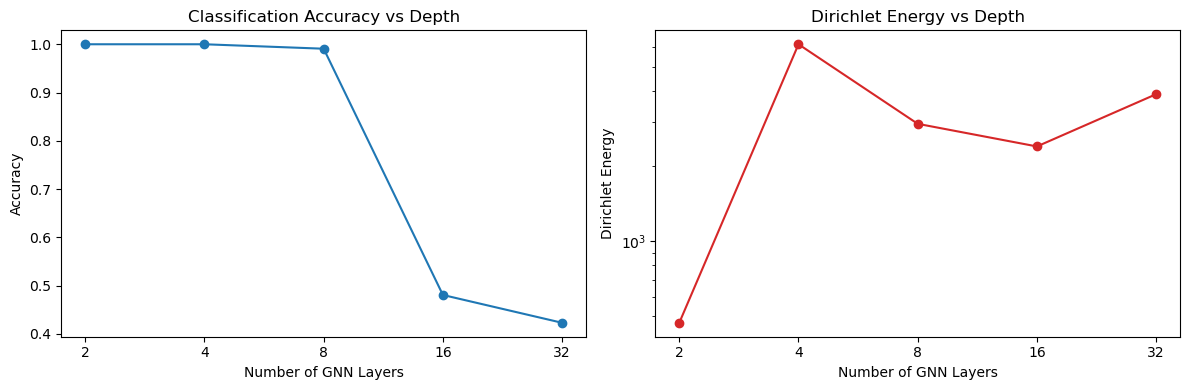

In [27]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(results["depth"], results["accuracy"], "o-", color="tab:blue")
ax1.set_xlabel("Number of GNN Layers")
ax1.set_ylabel("Accuracy")
ax1.set_title("Classification Accuracy vs Depth")
ax1.set_xscale("log", base=2)
ax1.set_xticks(depths)
ax1.set_xticklabels(depths)

ax2.plot(results["depth"], results["dirichlet"], "o-", color="tab:red")
ax2.set_xlabel("Number of GNN Layers")
ax2.set_ylabel("Dirichlet Energy")
ax2.set_title("Dirichlet Energy vs Depth")
ax2.set_xscale("log", base=2)
ax2.set_yscale("log")
ax2.set_xticks(depths)
ax2.set_xticklabels(depths)

plt.tight_layout()
plt.show()

<div class="alert alert-warning">
    <h3>Question 2.2 [1 pt]</h3>
    <ol>
        <li>The <b>Dirichlet energy</b> \(E(\mathbf{H}) = \frac{1}{N}\sum_{(i,j)\in\mathcal{E}} \|\mathbf{h}_i - \mathbf{h}_j\|^2\) measures how much node embeddings vary across edges. What does a <b>high</b> vs <b>low</b> Dirichlet energy mean for node classification? What value does it approach in the limit of infinite depth, and why?</li>
        <li>Based on your plots, at which depth does oversmoothing start to visibly degrade accuracy? Would the answer change on a graph with larger diameter?</li>
    </ol>
    Write your answer in the cell below.
<br><i>Note: answering one part thoroughly is sufficient for full credit. You do not need to provide proofs here, intuitive arguments are perfectly fine.</i>
</div>

*Your answer here.*

A high Dirichlet energy means neighboring embeddings remain different and class-separable, while a low energy means they become too similar. With infinite depth, it approaches 0 because repeated message passing smooths all node representations.

Based on the plots, oversmoothing starts to visibly degrade accuracy around depth 16, where accuracy drops strongly compared to depths 2,4, and 8. On a graph with larger diameter, this degradation might occur at greater depth, because nodes need more message-passing layers before they effectively mix information from the whole graph.

<div class="alert alert-warning">
    <h3>Task 2.3: Skip Connections [1 pt]</h3>
    Modify <code>DeepGNN</code> to add a <b>residual connection</b> at each hidden layer:
    \[\mathbf{h}^{(k+1)} = \mathbf{h}^{(k)} + \text{GNNLayer}(\mathbf{h}^{(k)})\]
    Re-run the depth experiment from Task 2.1 and compare accuracy with and without skip connections.<br>
    <i>Tip: the skip connection only applies to hidden layers where input and output dimensions match — not the first or last layer.</i>
</div>

In [28]:
class ResidualGNN(nn.Module):
    def __init__(self, in_d, hidden_d, out_d, n_layers):
        super().__init__()
        # YOUR CODE HERE
        
        self.input_layer = GNNLayer(in_d, hidden_d)

        self.hidden_layers = nn.ModuleList()
        for _ in range(n_layers - 2):
            self.hidden_layers.append(GNNLayer(hidden_d, hidden_d))

        self.output_layer = GNNLayer(hidden_d, out_d, activation=None)

    def forward(self, x, adj):
        # YOUR CODE HERE
        
        h = self.input_layer(x, adj)

        for layer in self.hidden_layers:
            h = h + layer(h, adj)

        h = self.output_layer(h, adj)

        return h


results_skip = depth_scan(ResidualGNN, depths)

Depth: 02 | Accuracy: 1.0000 | Dirichlet Energy: 481.2204
Depth: 04 | Accuracy: 1.0000 | Dirichlet Energy: 3314.6902
Depth: 08 | Accuracy: 0.9967 | Dirichlet Energy: 9854.7930
Depth: 16 | Accuracy: 0.9727 | Dirichlet Energy: 3415.7688
Depth: 32 | Accuracy: 0.7426 | Dirichlet Energy: 21017.6680


<div class="alert alert-info">
    <h3>Skip Connection Comparison</h3>
    Nothing to do here, just run the cell.
</div>

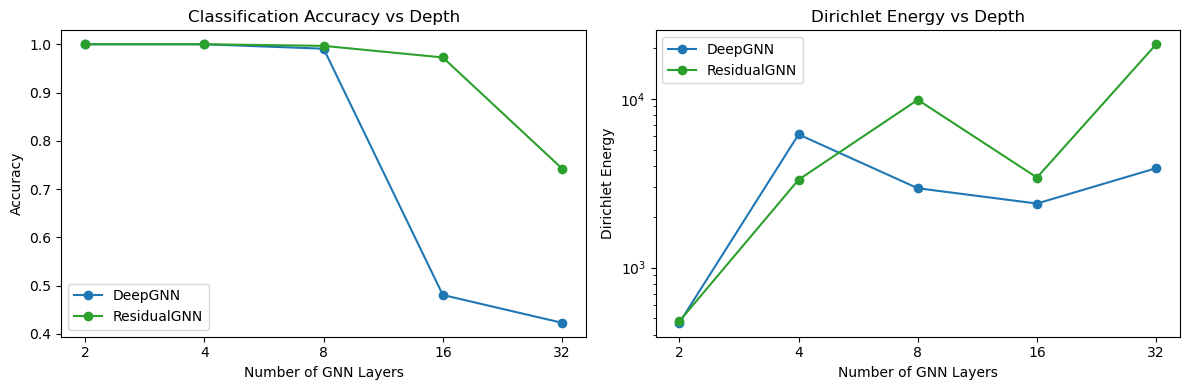

In [29]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(depths, results["accuracy"], "o-", label="DeepGNN", color="tab:blue")
ax1.plot(depths, results_skip["accuracy"], "o-", label="ResidualGNN", color="tab:green")
ax1.set_xlabel("Number of GNN Layers")
ax1.set_ylabel("Accuracy")
ax1.set_title("Classification Accuracy vs Depth")
ax1.set_xscale("log", base=2)
ax1.set_xticks(depths)
ax1.set_xticklabels(depths)
ax1.legend()

ax2.plot(depths, results["dirichlet"], "o-", label="DeepGNN", color="tab:blue")
ax2.plot(depths, results_skip["dirichlet"], "o-", label="ResidualGNN", color="tab:green")
ax2.set_xlabel("Number of GNN Layers")
ax2.set_ylabel("Dirichlet Energy")
ax2.set_title("Dirichlet Energy vs Depth")
ax2.set_xscale("log", base=2)
ax2.set_yscale("log")
ax2.set_xticks(depths)
ax2.set_xticklabels(depths)
ax2.legend()

plt.tight_layout()
plt.show()

# Part 3: Equivariant Graph Neural Networks

Standard GNNs are **permutation equivariant** at the node level but break symmetry when node features include **positions**. Rotating the input coordinates does not produce a correspondingly rotated output.

**E(n) Equivariant GNNs** (Satorras, Hoogeboom & Welling, *E(n) Equivariant Graph Neural Networks*, ICML 2021, arXiv:2102.09844) fix this by maintaining two separate information paths:

- **Scalar path** (invariant): node features $\mathbf{h}_i$ and edge messages $m_{ij}$ — these do not transform under rotation.
- **Vector path** (equivariant): coordinates $\mathbf{x}_i$ and relative displacements $(\mathbf{x}_i - \mathbf{x}_j)$ — these rotate with the input.

The key design principle: the scalar path only sees **invariant** geometric quantities ($\|\mathbf{x}_i - \mathbf{x}_j\|^2$), while the vector path is updated using relative displacements scaled by **scalars** from the scalar path. Following Eqs. (3)-(7):

$$
m_{ij} = \phi_e\left(\mathbf{h}_i^l, \mathbf{h}_j^l, \|\mathbf{x}_i^l - \mathbf{x}_j^l\|^2\right) \quad \text{(scalar: invariant)}
$$
$$
\mathbf{x}_i^{l+1} = \mathbf{x}_i^l + \frac{1}{|\mathcal{N}(i)|} \sum_{j \in \mathcal{N}(i)} (\mathbf{x}_i^l - \mathbf{x}_j^l) \, \phi_x(m_{ij}) \quad \text{(vector: equivariant)}
$$
$$
\mathbf{h}_i^{l+1} = \phi_h\left(\mathbf{h}_i^l, \sum_{j \in \mathcal{N}(i)} m_{ij}\right) \quad \text{(scalar: invariant)}
$$

<div class="alert alert-info">
    <h3>Utility: Gravitational 5-Body Dataset</h3>
    Nothing to do here, just run the cell. We generate a simple 2D gravity simulation: particles interact via gravity, and the task is to predict their final positions given initial positions and velocities.
</div>

In [30]:
def generate_nbody_data(n_samples=1000, n_bodies=5, n_steps=20, dt=0.005):
    """Generates 2D gravitational n-body trajectories."""
    init_positions = []
    init_velocities = []
    final_positions = []

    for _ in range(n_samples):
        pos = np.random.randn(n_bodies, 2) * 0.5
        vel = np.random.randn(n_bodies, 2) * 0.1

        init_positions.append(pos.copy())
        init_velocities.append(vel.copy())

        for _ in range(n_steps):
            forces = np.zeros_like(pos)
            for i in range(n_bodies):
                for j in range(n_bodies):
                    if i != j:
                        diff = pos[j] - pos[i]
                        dist = np.linalg.norm(diff) + 0.1  # softened gravity
                        forces[i] += diff / (dist ** 3)
            vel = vel + forces * dt
            pos = pos + vel * dt

        final_positions.append(pos.copy())

    return (
        torch.FloatTensor(np.array(init_positions)).to(device),
        torch.FloatTensor(np.array(init_velocities)).to(device),
        torch.FloatTensor(np.array(final_positions)).to(device),
    )


pos_init, vel_init, pos_target = generate_nbody_data(n_samples=500, n_steps=50)

n_bodies = pos_init.shape[1]
adj_nbody = (torch.ones(n_bodies, n_bodies) - torch.eye(n_bodies)).to(device)

n_train = int(0.8 * len(pos_init))
train_pos, test_pos = pos_init[:n_train], pos_init[n_train:]
train_vel, test_vel = vel_init[:n_train], vel_init[n_train:]
train_target, test_target = pos_target[:n_train], pos_target[n_train:]

print(f"Initial positions: {pos_init.shape}")
print(f"Initial velocities: {vel_init.shape}")
print(f"Target positions: {pos_target.shape}")
print(f"Adjacency: {adj_nbody.shape}")

Initial positions: torch.Size([500, 5, 2])
Initial velocities: torch.Size([500, 5, 2])
Target positions: torch.Size([500, 5, 2])
Adjacency: torch.Size([5, 5])


<div class="alert alert-warning">
    <h3>Task 3.1: EGNN Layer Implementation [1 pt]</h3>
    Implement the <code>EGNNLayer</code> following the two-path structure described above.
    <br><br>
    <b>(a) Edge messages (scalar path):</b> Compute relative displacements \((\mathbf{x}_i - \mathbf{x}_j)\) and their squared norms \(\|\mathbf{x}_i - \mathbf{x}_j\|^2\). Feed node features and squared distances (not raw coordinates!) into \(\phi_e\) to produce edge messages \(m_{ij}\).
    <br><br>
    <b>(b) Node and coordinate updates (scalar + vector paths):</b>
    <ul>
        <li><b>Vector path:</b> update coordinates equivariantly — scale relative displacements by the learned scalar \(\phi_x(m_{ij})\) and aggregate.</li>
        <li><b>Scalar path:</b> update node features by aggregating edge messages and passing through \(\phi_h\).</li>
    </ul>
    <i>Tip: the edge MLP takes \(2 \cdot \text{hidden} + 1\) inputs (two node features + one squared distance). The coord MLP outputs a single scalar per edge.</i>
</div>

In [31]:
class EGNNLayer(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        # YOUR CODE HERE
        
        self.edge_mlp = nn.Sequential(
            nn.Linear(2 * hidden_dim + 1, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU()
        )

        self.coord_mlp = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )

        self.node_mlp = nn.Sequential(
            nn.Linear(2 * hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )

    def forward(self, h, x, adj):
        """
        Args:
            h: node features (N, hidden_dim)
            x: node coordinates (N, 2)
            adj: adjacency matrix (N, N), no self-loops
        Returns:
            h_new: (N, hidden_dim), x_new: (N, 2)
        """
        # YOUR CODE HERE
        
        N = h.shape[0]

        h_i = h.unsqueeze(1).expand(N, N, -1)
        h_j = h.unsqueeze(0).expand(N, N, -1)

        x_i = x.unsqueeze(1).expand(N, N, -1)
        x_j = x.unsqueeze(0).expand(N, N, -1)

        rel = x_i - x_j

        dist2 = rel.pow(2).sum(dim=-1, keepdim=True)

        edge_input = torch.cat([h_i, h_j, dist2], dim=-1)

        m_ij = self.edge_mlp(edge_input)

        mask = adj.unsqueeze(-1)

        m_ij = m_ij * mask

        coord_weights = self.coord_mlp(m_ij)

        coord_update = rel * coord_weights * mask

        deg = adj.sum(dim=1, keepdim=True).clamp(min=1)

        x_new = x + coord_update.sum(dim=1) / deg

        m_i = m_ij.sum(dim=1)

        node_input = torch.cat([h, m_i], dim=-1)

        h_new = self.node_mlp(node_input)

        return h_new, x_new

<div class="alert alert-info">
    <h3>Equivariance Verification</h3>
    We test equivariance on random inputs before training. A layer is <b>equivariant</b> to rotation \(R\) if:
    \[f(R \cdot \mathbf{x}) = R \cdot f(\mathbf{x})\]
    The EGNN layer should produce near-zero error. The standard GNNLayer, treating coordinates as ordinary features, does not.
</div>

In [32]:
# rotation matrix (45 degrees)
theta = torch.tensor(np.pi / 4)
R = torch.tensor([[torch.cos(theta), -torch.sin(theta)],
                   [torch.sin(theta),  torch.cos(theta)]]).to(device)

torch.manual_seed(0)
N, hidden_dim = 5, 16
h_test = torch.randn(N, hidden_dim).to(device)
x_test = torch.randn(N, 2).to(device)
adj_test = (torch.ones(N, N) - torch.eye(N)).to(device)

# EGNN: coordinate output should rotate with the input
egnn_layer = EGNNLayer(hidden_dim).to(device)
egnn_layer.eval()
with torch.no_grad():
    _, x_out = egnn_layer(h_test, x_test, adj_test)
    _, x_out_from_rot = egnn_layer(h_test, x_test @ R.T, adj_test)
    err_egnn = (x_out @ R.T - x_out_from_rot).norm().item()

# GNNLayer: coordinates concatenated as features, no equivariance guarantee
gnn_layer = GNNLayer(hidden_dim + 2, 2, activation=None).to(device)
gnn_layer.eval()
with torch.no_grad():
    adj_self = adj_test + torch.eye(N, device=device)
    gnn_out = gnn_layer(torch.cat([h_test, x_test], dim=-1), adj_self)
    gnn_out_rot = gnn_layer(torch.cat([h_test, x_test @ R.T], dim=-1), adj_self)
    err_gnn = (gnn_out @ R.T - gnn_out_rot).norm().item()

print("Equivariance error (lower = better):")
print(f"  EGNN Layer: {err_egnn:.6f}")
print(f"  GNN Layer:  {err_gnn:.6f}")

Equivariance error (lower = better):
  EGNN Layer: 0.000000
  GNN Layer:  1.691766


<div class="alert alert-warning">
    <h3>Task 3.2: EGNN Training & Comparison [1 pt]</h3>
    <ol>
        <li>Train both with <b>MSE loss</b> on predicted vs. target positions. A few epochs (50) should be enough.</li>
        <li>Report test MSE for both. You should get ~5-10x lower loss for EGNN.</li>
    </ol>
    <i>Tip: use velocities as node features. For the EGNN, positions are the equivariant coordinates. For the GNN baseline, concatenate positions into the feature vector.</i><br>
    <b>Note: Training these two models might take a few minutes on CPU.</b>
</div>

In [33]:
class EGNNModel(nn.Module):
    def __init__(self, in_dim, hidden_dim):
        super().__init__()
        self.embed = nn.Linear(in_dim, hidden_dim)
        self.layer1 = EGNNLayer(hidden_dim)
        self.layer2 = EGNNLayer(hidden_dim)

    def forward(self, h, x, adj):
        h = F.relu(self.embed(h))
        h, x = self.layer1(h, x, adj)
        h, x = self.layer2(h, x, adj)
        return x


class GNNBaseline(nn.Module):
    """Standard GNN treating coordinates as regular features."""
    def __init__(self, in_dim, hidden_dim, coord_dim=2):
        super().__init__()
        self.l1 = GNNLayer(in_dim + coord_dim, hidden_dim)
        self.l2 = GNNLayer(hidden_dim, coord_dim, activation=None)

    def forward(self, h, x, adj):
        adj_self = adj + torch.eye(adj.shape[0], device=adj.device)
        return self.l2(self.l1(torch.cat([h, x], dim=-1), adj_self), adj_self)


egnn_model = EGNNModel(in_dim=2, hidden_dim=64).to(device)
gnn_baseline = GNNBaseline(in_dim=2, hidden_dim=64).to(device)

# YOUR CODE HERE

def train_nbody_model(model, train_pos, train_vel, train_target, adj, epochs=50, lr=1e-3):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    for epoch in range(epochs):
        model.train()
        total_loss = 0.0

        for pos, vel, target in zip(train_pos, train_vel, train_target):
            optimizer.zero_grad()

            pred = model(vel, pos, adj)

            loss = F.mse_loss(pred, target)

            loss.backward()

            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(train_pos)

        if epoch % 10 == 0:
            print(f"Epoch {epoch:03d} | Train MSE: {avg_loss:.6f}")

    return model


def test_nbody_model(model, test_pos, test_vel, test_target, adj):
    model.eval()
    total_loss = 0.0

    with torch.no_grad():
        for pos, vel, target in zip(test_pos, test_vel, test_target):
            pred = model(vel, pos, adj)
            loss = F.mse_loss(pred, target)
            total_loss += loss.item()

    return total_loss / len(test_pos)


print("Training EGNN...")
egnn_model = train_nbody_model(
    egnn_model,
    train_pos,
    train_vel,
    train_target,
    adj_nbody,
    epochs=50,
    lr=1e-3
)

print("Training GNN baseline...")
gnn_baseline = train_nbody_model(
    gnn_baseline,
    train_pos,
    train_vel,
    train_target,
    adj_nbody,
    epochs=50,
    lr=1e-3
)

egnn_test_mse = test_nbody_model(
    egnn_model,
    test_pos,
    test_vel,
    test_target,
    adj_nbody
)

gnn_test_mse = test_nbody_model(
    gnn_baseline,
    test_pos,
    test_vel,
    test_target,
    adj_nbody
)

print(f"EGNN Test MSE: {egnn_test_mse:.6f}")
print(f"GNN Baseline Test MSE: {gnn_test_mse:.6f}")
print(f"Improvement factor: {gnn_test_mse / egnn_test_mse:.2f}x")

Training EGNN...
Epoch 000 | Train MSE: 0.006588
Epoch 010 | Train MSE: 0.001027
Epoch 020 | Train MSE: 0.000924
Epoch 030 | Train MSE: 0.000869
Epoch 040 | Train MSE: 0.000819
Training GNN baseline...
Epoch 000 | Train MSE: 0.157171
Epoch 010 | Train MSE: 0.013038
Epoch 020 | Train MSE: 0.010088
Epoch 030 | Train MSE: 0.008890
Epoch 040 | Train MSE: 0.009317
EGNN Test MSE: 0.000914
GNN Baseline Test MSE: 0.009324
Improvement factor: 10.21x


<div class="alert alert-info">
    <h3>Prediction Visualization</h3>
    Nothing to do here, just run the cell.
</div>

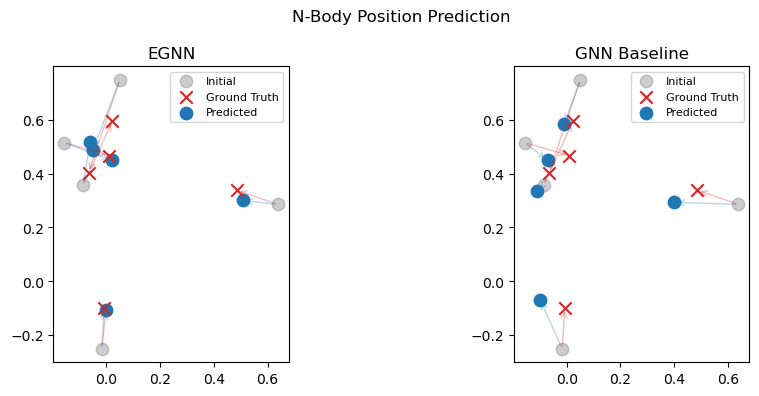

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sample_idx = 0
with torch.no_grad():
    pred_e = egnn_model(test_vel[sample_idx], test_pos[sample_idx], adj_nbody).cpu().numpy()
    pred_g = gnn_baseline(test_vel[sample_idx], test_pos[sample_idx], adj_nbody).cpu().numpy()
    true = test_target[sample_idx].cpu().numpy()
    init = test_pos[sample_idx].cpu().numpy()

for ax, preds, title in zip(axes, [pred_e, pred_g], ["EGNN", "GNN Baseline"]):
    ax.scatter(init[:, 0], init[:, 1], c="gray", s=80, alpha=0.4, label="Initial", zorder=1)
    ax.scatter(true[:, 0], true[:, 1], c="tab:red", s=80, marker="x", label="Ground Truth", zorder=3)
    ax.scatter(preds[:, 0], preds[:, 1], c="tab:blue", s=80, label="Predicted", zorder=2)
    for k in range(n_bodies):
        ax.annotate("", xy=true[k], xytext=init[k],
                     arrowprops=dict(arrowstyle="->", color="tab:red", alpha=0.3))
        ax.annotate("", xy=preds[k], xytext=init[k],
                     arrowprops=dict(arrowstyle="->", color="tab:blue", alpha=0.3))
    ax.set_title(title)
    ax.set_aspect("equal")
    ax.legend(fontsize=8)
plt.suptitle("N-Body Position Prediction")
plt.tight_layout()
plt.show()

<div class="alert alert-warning">
    <h3>Question 3.3 [1 pts]</h3>
    <b>(a)</b> Consider the EGNN coordinate update: \(\mathbf{x}_i' = \mathbf{x}_i + \frac{1}{|\mathcal{N}(i)|}\sum_{j} (\mathbf{x}_i - \mathbf{x}_j)\,\phi_x(m_{ij})\). Show that if we apply a rotation \(R\) to all input coordinates, the output coordinates are also rotated by \(R\). <i>Hint: substitute \(R\mathbf{x}_i\) for \(\mathbf{x}_i\). Rotations are orthogonal matrices and thereby leave norms unchanged. Which quantities belong to the scalar path (invariant under \(R\)) and which to the vector path (transform with \(R\))?</i><br>
    <b>(b)</b> The GNNBaseline concatenates coordinates into the feature vector. Explain why this mixes the scalar and vector paths, breaking equivariance.<br><br>
    Write your answer in the cell below.
    <br><i>Note: answering one part thoroughly is sufficient for full credit.</i>
</div>

*Your answer here.*

For the EGNN, distances between nodes stay the same under rotation, so the scalar messages and learned weights do not change. The relative direction vectors rotate with the input, so the coordinate update also rotates in the same way, meaning the output positions rotate consistently.

The GNN baseline simply treats coordinates like normal features by concatenating them with velocities. This mixes scalar information and geometric vector information, so after rotating the input coordinates, the model is not forced to produce an equally rotated output.